In [31]:
import geopandas as gpd
import pandas as pd
import numpy as np

BASE = "/home/jovyan/work/children15mc"
PROC = f"{BASE}/data/processed"
OUT  = f"{BASE}/outputs"
import os; os.makedirs(OUT, exist_ok=True)

df = gpd.read_file(f"{PROC}/accessibility_comparison.gpkg")
print(f"LSOAs: {len(df)}")

df = df.dropna(subset=["score_d", "score_b", "idaci_score"]).copy()
print(f"With complete data: {len(df)}")

df["idaci_q"] = pd.qcut(df["idaci_score"], 4,
                        labels=["Q1 (least deprived)", "Q2", "Q3", "Q4 (most deprived)"])

df["loss_abs"] = df["score_d"] - df["score_b"]
df["loss_pct"] = np.where(df["score_d"] > 0,
                          100 * df["loss_abs"] / df["score_d"], np.nan)

print(df["idaci_q"].value_counts().sort_index())

LSOAs: 4994
With complete data: 4964
idaci_q
Q1 (least deprived)    1254
Q2                     1228
Q3                     1254
Q4 (most deprived)     1228
Name: count, dtype: int64


In [32]:
summary = df.groupby("idaci_q", observed=True).agg(
    n_lsoa        = ("lsoa21cd", "count"),
    child_pop     = ("child_pop", "sum"),
    mean_score_d  = ("score_d", "mean"),
    mean_score_b  = ("score_b", "mean"),
    mean_loss_abs = ("loss_abs", "mean"),
    mean_loss_pct = ("loss_pct", "mean"),
    median_loss_pct = ("loss_pct", "median"),
).round(2)

print("=== Accessibility loss by IDACI quartile ===")
print(summary)
summary.to_csv(f"{OUT}/equity_by_quartile.csv")

q1 = summary.iloc[0]; q4 = summary.iloc[-1]
print(f"\nQ1 mean loss: {q1.mean_loss_pct:.1f}%  |  Q4 mean loss: {q4.mean_loss_pct:.1f}%")
print(f"Difference: {q4.mean_loss_pct - q1.mean_loss_pct:.1f} percentage points")

=== Accessibility loss by IDACI quartile ===
                     n_lsoa  child_pop  mean_score_d  mean_score_b  \
idaci_q                                                              
Q1 (least deprived)    1254     355835          5.17          2.80   
Q2                     1228     392894          5.64          3.17   
Q3                     1254     419003          7.48          4.46   
Q4 (most deprived)     1228     417802         10.30          6.75   

                     mean_loss_abs  mean_loss_pct  median_loss_pct  
idaci_q                                                             
Q1 (least deprived)           2.37          47.04            50.00  
Q2                            2.46          45.38            42.86  
Q3                            3.02          42.50            39.13  
Q4 (most deprived)            3.56          35.88            30.00  

Q1 mean loss: 47.0%  |  Q4 mean loss: 35.9%
Difference: -11.2 percentage points


In [33]:
from scipy.stats import pearsonr, spearmanr

sub = df.dropna(subset=["loss_pct"])
r_p, p_p = pearsonr(sub["idaci_score"], sub["loss_pct"])
r_s, p_s = spearmanr(sub["idaci_score"], sub["loss_pct"])

print(f"Pearson  r = {r_p:.3f} (p = {p_p:.2e})")
print(f"Spearman r = {r_s:.3f} (p = {p_s:.2e})")

Pearson  r = -0.113 (p = 2.83e-15)
Spearman r = -0.109 (p = 2.61e-14)


In [34]:
HIGH_LOSS = 50
hi_loss = df["loss_pct"] >= HIGH_LOSS
hi_dep  = df["idaci_q"] == "Q4 (most deprived)"

overlap = df[hi_loss & hi_dep]
total_children = df["child_pop"].sum()

print(f"=== Overlap: high loss (≥{HIGH_LOSS}%) AND most deprived quartile ===")
print(f"LSOAs: {len(overlap)} ({100*len(overlap)/len(df):.1f}% of all)")
print(f"Children aged 0–14: {int(overlap['child_pop'].sum()):,}")
print(f"  = {100*overlap['child_pop'].sum()/total_children:.1f}% of London's 0–14 population")

contrast = df[(df["loss_pct"] < HIGH_LOSS) & (df["idaci_q"] == "Q1 (least deprived)")]
print(f"\nContrast (low loss, least deprived): {len(contrast)} LSOAs, "
      f"{int(contrast['child_pop'].sum()):,} children")

df["loss_group"] = np.where(df["loss_pct"] >= HIGH_LOSS, "High loss", "Lower loss")
matrix = df.pivot_table(index="idaci_q", columns="loss_group",
                        values="child_pop", aggfunc="sum", observed=True).fillna(0).astype(int)
print("\n=== Children by deprivation × loss ===")
print(matrix)
matrix.to_csv(f"{OUT}/children_by_deprivation_loss.csv")

=== Overlap: high loss (≥50%) AND most deprived quartile ===
LSOAs: 422 (8.5% of all)
Children aged 0–14: 154,398
  = 9.7% of London's 0–14 population

Contrast (low loss, least deprived): 585 LSOAs, 159,918 children

=== Children by deprivation × loss ===
loss_group           High loss  Lower loss
idaci_q                                   
Q1 (least deprived)     183970      171865
Q2                      193135      199759
Q3                      192651      226352
Q4 (most deprived)      154398      263404


In [35]:
# 3×3 bivariate classification
valid = df["loss_pct"].notna() & df["idaci_score"].notna()
print(f"Classifiable LSOAs: {valid.sum()} / {len(df)} "
      f"({(~valid).sum()} excluded, default score = 0)")

df["loss_t"] = np.nan
df["idaci_t"] = np.nan
df.loc[valid, "loss_t"] = pd.qcut(
    df.loc[valid, "loss_pct"].rank(method="first"), 3, labels=[1, 2, 3]).astype(int)
df.loc[valid, "idaci_t"] = pd.qcut(
    df.loc[valid, "idaci_score"].rank(method="first"), 3, labels=[1, 2, 3]).astype(int)

# Build the bivariate label only where both tertiles exist
df["bivar"] = np.where(
    valid,
    df["idaci_t"].fillna(0).astype(int).astype(str) + "-" +
    df["loss_t"].fillna(0).astype(int).astype(str),
    "no data")

print(df["bivar"].value_counts().sort_index())

n33 = (df["bivar"] == "3-3").sum()
c33 = int(df.loc[df["bivar"] == "3-3", "child_pop"].sum())
print(f"\n3-3 = highest deprivation + highest loss (priority areas)")
print(f"  LSOAs: {n33}, children aged 0–14: {c33:,}")

# Export for QGIS
cols = ["lsoa21cd", "lad22nm", "idaci_score", "idaci_q", "child_pop",
        "score_d", "score_b", "loss_abs", "loss_pct",
        "idaci_t", "loss_t", "bivar", "geometry"]
export = df[[c for c in cols if c in df.columns]].copy()
export["idaci_q"] = export["idaci_q"].astype(str)
export.to_file(f"{OUT}/equity_for_qgis.gpkg", driver="GPKG")
print(f"\n✓ Exported {len(export)} LSOAs to equity_for_qgis.gpkg")

zero_default = (df["score_d"] == 0).sum()
print(f"LSOAs with zero accessibility even under default network: {zero_default}")
print(f"  children affected: {int(df.loc[df['score_d']==0, 'child_pop'].sum()):,}")

Classifiable LSOAs: 4872 / 4964 (92 excluded, default score = 0)
bivar
1-1        499
1-2        495
1-3        630
2-1        518
2-2        514
2-3        592
3-1        607
3-2        615
3-3        402
no data     92
Name: count, dtype: int64

3-3 = highest deprivation + highest loss (priority areas)
  LSOAs: 402, children aged 0–14: 145,316

✓ Exported 4964 LSOAs to equity_for_qgis.gpkg
LSOAs with zero accessibility even under default network: 92
  children affected: 30,239


/tmp/ipykernel_52/181143045.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Q1\n(least)", "Q2", "Q3", "Q4\n(most)"],


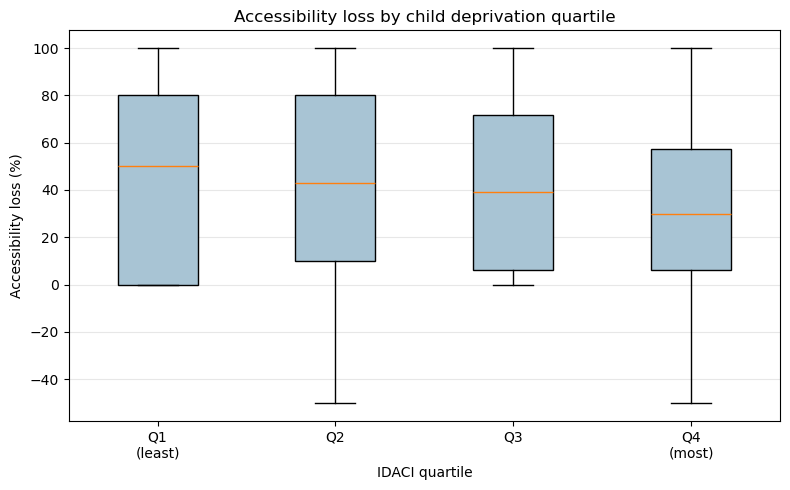

In [36]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
data = [df.loc[df["idaci_q"]==q, "loss_pct"].dropna()
        for q in df["idaci_q"].cat.categories]
bp = ax.boxplot(data, labels=["Q1\n(least)", "Q2", "Q3", "Q4\n(most)"],
                showfliers=False, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#a8c4d4")
ax.set_xlabel("IDACI quartile")
ax.set_ylabel("Accessibility loss (%)")
ax.set_title("Accessibility loss by child deprivation quartile")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/loss_by_quartile.png", dpi=200)
plt.show()

In [37]:
zero_by_q = df.groupby("idaci_q", observed=True).apply(
    lambda g: pd.Series({
        "zero_default_pct": 100*(g.score_d==0).mean(),
        "zero_barrier_pct": 100*(g.score_b==0).mean(),
        "children_zero_barrier": int(g.loc[g.score_b==0,"child_pop"].sum())
    })).round(2)
print(zero_by_q)

                     zero_default_pct  zero_barrier_pct  children_zero_barrier
idaci_q                                                                       
Q1 (least deprived)              3.51             23.84                85385.0
Q2                               2.12             22.31                92526.0
Q3                               0.88             16.59                76007.0
Q4 (most deprived)               0.90              9.45                46791.0


/tmp/ipykernel_52/3707333582.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zero_by_q = df.groupby("idaci_q", observed=True).apply(


In [38]:
import numpy as np
df["dist_centre"] = np.hypot(df.cent_x - 530034, df.cent_y - 180381) / 1000

df["ring"] = pd.cut(df["dist_centre"], [0, 5, 10, 15, 100],
                    labels=["Inner (<5km)", "5-10km", "10-15km", "Outer (>15km)"])

ring_stats = df.groupby("ring", observed=True).agg(
    n=("lsoa21cd","count"),
    mean_score_d=("score_d","mean"),
    mean_score_b=("score_b","mean"),
    mean_loss_pct=("loss_pct","mean"),
    zero_barrier_pct=("score_b", lambda s: 100*(s==0).mean()),
    children=("child_pop","sum"),
).round(2)
print(ring_stats)

                  n  mean_score_d  mean_score_b  mean_loss_pct  \
ring                                                             
Inner (<5km)    540         14.74         10.42          28.56   
5-10km         1319          9.22          5.91          34.25   
10-15km        1418          5.94          3.37          42.62   
Outer (>15km)  1687          4.09          1.83          54.37   

               zero_barrier_pct  children  
ring                                       
Inner (<5km)               3.52    119145  
5-10km                     8.49    380816  
10-15km                   17.42    488660  
Outer (>15km)             30.76    596913  


In [39]:
iso_d = gpd.read_file(f"{PROC}/isochrones_all.gpkg")
iso_b = gpd.read_file(f"{PROC}/isochrones_barrier.gpkg")

import geopandas as gpd
df = gpd.read_file(f"{PROC}/accessibility_comparison.gpkg")

df["dist"] = ((df.cent_x-530034)**2 + (df.cent_y-180381)**2)**0.5 / 1000

cand = df[(df.loss_pct >= 70) &
          (df.child_pop >= df.child_pop.quantile(0.75)) &
          (df.score_b <= 1)].copy()

cand = cand.sort_values("child_pop", ascending=False)
print(f"Selected LSOA: {len(cand)}")
print(cand[["lsoa21cd","lad22nm","dist","score_d","score_b",
            "loss_pct","child_pop"]].head(15).to_string())

print("\n borough:")
print(cand.lad22nm.value_counts().head())

Selected LSOA: 313
       lsoa21cd               lad22nm       dist  score_d  score_b    loss_pct  child_pop
3914  E01003666             Redbridge  18.673753      3.0      0.0  100.000000        825
54    E01034471  Barking and Dagenham  17.261525      7.0      0.0  100.000000        718
1221  E01001027               Croydon  21.586812      1.0      0.0  100.000000        717
61    E01000099  Barking and Dagenham  19.118960      4.0      0.0  100.000000        711
1604  E01033926               Enfield  16.558633      6.0      0.0  100.000000        709
2757  E01002620              Hounslow  17.564979      6.0      0.0  100.000000        690
2133  E01002034              Haringey  11.822372      9.0      1.0   88.888889        689
64    E01000114  Barking and Dagenham  20.189023      1.0      0.0  100.000000        680
1072  E01001181               Croydon  13.348912      7.0      0.0  100.000000        646
604   E01000577                 Brent  13.399697      3.0      0.0  100.000000   

In [45]:
for code in ["E01004275", "E01002034", "E01001804", "E01002526"]:
    d = iso_d[iso_d.lsoa21cd==code]
    b = iso_b[iso_b.lsoa21cd==code]
    print(f"{code}: {d.area.iloc[0]/1e6:.3f} → {b.area.iloc[0]/1e6:.3f} km²")

E01004275: 1.038 → 0.169 km²
E01002034: 1.476 → 0.419 km²
E01001804: 1.540 → 0.296 km²
E01002526: 1.401 → 0.423 km²


In [46]:
case_d = iso_d[iso_d.lsoa21cd=="E01004275"]
case_b = iso_b[iso_b.lsoa21cd=="E01004275"]
s_d = gpd.sjoin(schools, case_d, predicate="within")
s_b = gpd.sjoin(schools, case_b, predicate="within")
print(f"Default school: {len(s_d)}")
print(s_d[["EstablishmentName"]].to_string())
print(f"\nBarrier School: {len(s_b)}")
if len(s_b): print(s_b[["EstablishmentName"]].to_string())

Default school: 3
                      EstablishmentName
902            Harbinger Primary School
949         St Edmund's Catholic School
36283  Canary Wharf College, East Ferry

Barrier School: 1
            EstablishmentName
902  Harbinger Primary School


In [47]:
neg = df[df.loss_abs < 0]
print(f"LSOA: {len(neg)} ({100*len(neg)/len(df):.2f}%)")
if len(neg):
    print(neg[["lsoa21cd","score_d","score_b","loss_abs"]].head(10).to_string())
    print(f"max: {neg.loss_abs.min()}")

LSOA: 6 (0.12%)
       lsoa21cd  score_d  score_b  loss_abs
102   E01000096      0.0      2.0      -2.0
104   E01034475      2.0      3.0      -1.0
397   E01000469      2.0      4.0      -2.0
3580  E01003470      2.0      3.0      -1.0
4523  E01004249     19.0     20.0      -1.0
4838  E01004510      2.0     19.0     -17.0
max: -17.0
